In [21]:
from matplotlib import pyplot as plt
import numpy as np
import PIL 
import glob
plt.rcParams['font.family']='serif'
import os

In [22]:
files = sorted(glob.glob("VIS_POLI_VS_MAG_SIC/Vis_*X_SiC*.raw"))
print(files)

['VIS_POLI_VS_MAG_SIC/Vis_1.5X_SiC__d0.5m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_1X_SiC__d0.1m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_2.5X_SiC__d0.9m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_2X_SiC__d0.75m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_3.5X_SiC__d1.08m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_3X_SiC__d1m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_4.5X_SiC__d1.17m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_4X_SiC__d1.13m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_5.5X_SiC__d1.23m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_5X_SiC__d1.2m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_6X_SiC__d1.25m_a15um_p62um_step-4.2_dith23.25_1.raw']


['VIS_POLI_VS_MAG_SIC/Vis_1.5X_SiC__d0.5m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_1X_SiC__d0.1m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_2.5X_SiC__d0.9m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_2X_SiC__d0.75m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_3.5X_SiC__d1.08m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_3X_SiC__d1m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_4.5X_SiC__d1.17m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_4X_SiC__d1.13m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_5.5X_SiC__d1.23m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_5X_SiC__d1.2m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_6X_SiC__d1.25m_a15um_p62um_step-4.2_dith23.25_1.raw']
Ploteando: VIS_POLI_VS_MAG_SIC/Vis_5.5X_SiC__d1.23m_a15um_p62um_step-4.2_dith23.25_1.raw
Elementos leídos: 65536


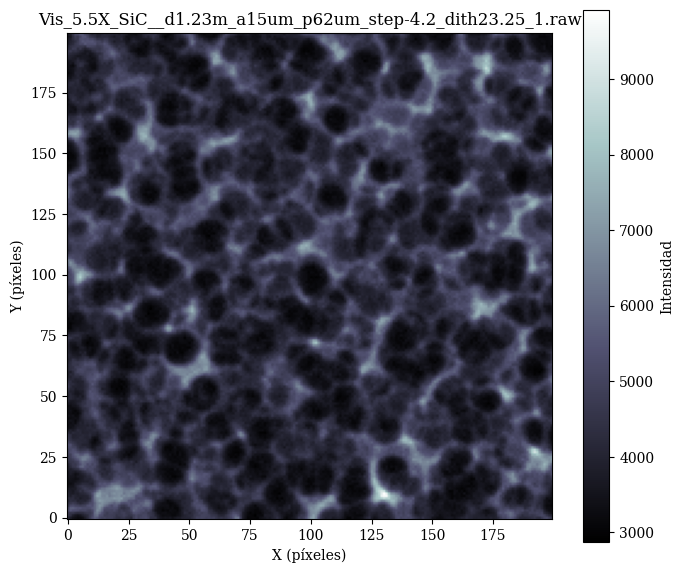

In [23]:
import glob
import numpy as np
import matplotlib.pyplot as plt

files = sorted(glob.glob("VIS_POLI_VS_MAG_SIC/Vis_*X_SiC*.raw"))
print(files)

# Elige el archivo que quieres plotear (índice 0 = primero)
file_idx = 8
file_path = files[file_idx]
print(f"Ploteando: {file_path}")

# Dimensiones de la imagen (ajusta según tu detector)
nx, ny = 256, 256

# Leer el archivo raw
data = np.fromfile(file_path, dtype=np.float32)  # cambia dtype si es float64, int32, etc.
print(f"Elementos leídos: {len(data)}")

# Reshape a imagen 2D
image = data.reshape((ny, nx))[25:225, 25:225]  # Ajusta el recorte según tus necesidades

# Plot
plt.figure(figsize=(7, 6))
plt.imshow(image, cmap='bone', origin='lower')
plt.colorbar(label='Intensidad')
plt.title(file_path.split("/")[-1])
plt.xlabel("X (píxeles)")
plt.ylabel("Y (píxeles)")
plt.tight_layout()
plt.show()

In [24]:
import numpy as np

def compute_visibility(img, block=50):
    vis_values = []

    height, width = img.shape

    for x in range(0, height - block + 1, block):
        for y in range(0, width - block + 1, block):
            region = img[x:x+block, y:y+block]

            mu = np.mean(region)
            sigma = np.std(region)

            if mu > 0:
                vis_values.append(sigma / mu)

    vis_values = np.array(vis_values)

    visibility = np.mean(vis_values)
    visibility_err = np.std(vis_values) / len(vis_values)

    return visibility, visibility_err

In [25]:
vis_results = []
magnifications = []

for file in files:

    # Leer RAW
    data_array = np.fromfile(file, dtype='float32', count=256*256)
    img = data_array.reshape(256, 256)

    # Calcular VIS
    vis = compute_visibility(img)

    vis_results.append(vis)

    # Extraer el número de magnificación del nombre
    mag = file.split("Vis_")[1].split("X")[0]
    magnifications.append(float(mag))

print(magnifications)
print(vis_results)

[1.5, 1.0, 2.5, 2.0, 3.5, 3.0, 4.5, 4.0, 5.5, 5.0, 6.0]
[(0.23906921, 0.002415957748889923), (0.17840779, 0.00140816867351532), (0.2546551, 0.0022882835566997526), (0.25391057, 0.0023881159722805023), (0.24787842, 0.0023482435941696166), (0.24990298, 0.002260473519563675), (0.23556557, 0.002564532458782196), (0.2419946, 0.002400372624397278), (0.22353241, 0.0027198222279548644), (0.23232377, 0.0027376267313957213), (0.21724392, 0.0027154606580734254)]


In [26]:
idx = np.argsort(magnifications)
magnifications = np.array(magnifications)[idx]

vis_results = np.array(vis_results)[idx]

V = vis_results[:, 0]      # visibilidad
V_err = vis_results[:, 1]  # error

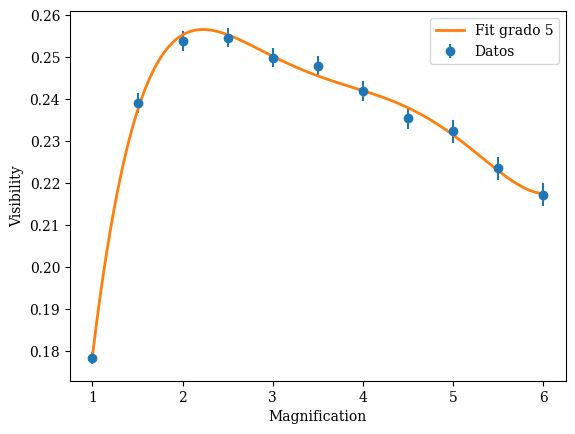

In [27]:


# Ordenar
idx = np.argsort(magnifications)
magnifications = np.array(magnifications)[idx]
vis_results = np.array(vis_results)[idx]

V = vis_results[:, 0]
V_err = vis_results[:, 1]

# Ajuste polinomial
grado = 5
coef = np.polyfit(magnifications, V, grado)
poly = np.poly1d(coef)

# Curva suave
x_fit = np.linspace(np.min(magnifications),
                    np.max(magnifications), 500)
y_fit = poly(x_fit)

# Gráfica
plt.errorbar(magnifications, V, yerr=V_err,
             fmt='o', label='Datos')

plt.plot(x_fit, y_fit, '-', lw=2,
         label=f'Fit grado {grado}')

plt.xlabel("Magnification")
plt.ylabel("Visibility")
plt.legend()
plt.show()

Parámetros ajustados:
  C1 = -0.65508 ± 0.18221
  C2 = 0.94277 ± 0.17892
  C3 = 2.25727 ± 0.21753
  C4 = 0.01264 ± 0.00334


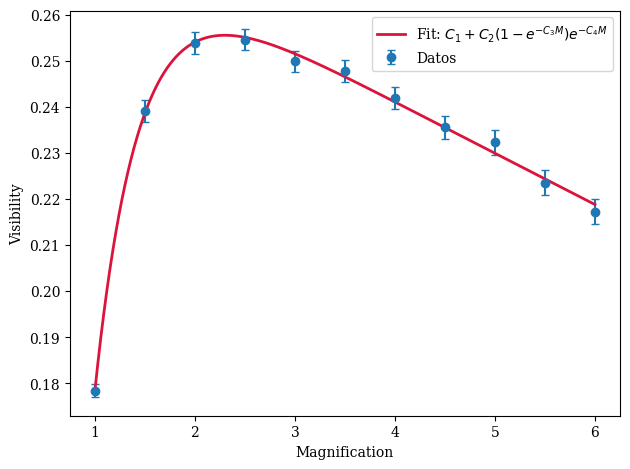

In [28]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# --- Tus datos ---
magnifications = [1.5, 1.0, 2.5, 2.0, 3.5, 3.0, 4.5, 4.0, 5.5, 5.0, 6.0]
vis_results = [(0.23906921, 0.002415957748889923), (0.17840779, 0.00140816867351532),
               (0.2546551, 0.0022882835566997526), (0.25391057, 0.0023881159722805023),
               (0.24787842, 0.0023482435941696166), (0.24990298, 0.002260473519563675),
               (0.23556557, 0.002564532458782196), (0.2419946, 0.002400372624397278),
               (0.22353241, 0.0027198222279548644), (0.23232377, 0.0027376267313957213),
               (0.21724392, 0.0027154606580734254)]

idx = np.argsort(magnifications)
magnifications = np.array(magnifications)[idx]
vis_results = np.array(vis_results)[idx]

V = vis_results[:, 0]
V_err = vis_results[:, 1]

# --- Modelo propuesto ---
def modelo(M, C1, C2, C3, C4):
    return C1 + C2 * (1 - np.exp(-C3 * M)) * np.exp(-C4 * M)

# --- Estimaciones iniciales (importantes para que converja bien) ---
# C1: valor base/asintótico bajo (ej. valor a M pequeño)
# C2: amplitud del pico
# C3: qué tan rápido sube
# C4: qué tan rápido decae después del pico
p0 = [0.15, 0.3, 2.0, 0.1]

# Bounds opcionales para evitar soluciones absurdas (todos positivos, por ejemplo)
bounds = ([-np.inf, -np.inf, 0, 0], [np.inf, np.inf, np.inf, np.inf])

popt, pcov = curve_fit(
    modelo, magnifications, V,
    p0=p0,
    sigma=V_err,        # fit ponderado por el error de cada punto
    absolute_sigma=True,
    bounds=bounds,
    maxfev=10000
)

perr = np.sqrt(np.diag(pcov))  # errores de los parámetros

print("Parámetros ajustados:")
for nombre, val, err in zip(['C1', 'C2', 'C3', 'C4'], popt, perr):
    print(f"  {nombre} = {val:.5f} ± {err:.5f}")

# --- Curva suave ---
x_fit = np.linspace(np.min(magnifications), np.max(magnifications), 500)
y_fit = modelo(x_fit, *popt)

# --- Gráfica ---
plt.errorbar(magnifications, V, yerr=V_err, fmt='o', label='Datos', capsize=3)
plt.plot(x_fit, y_fit, '-', lw=2, color='crimson',
         label='Fit: $C_1+C_2(1-e^{-C_3 M})e^{-C_4 M}$')
plt.xlabel("Magnification")
plt.ylabel("Visibility")
plt.legend()
plt.tight_layout()
plt.show()

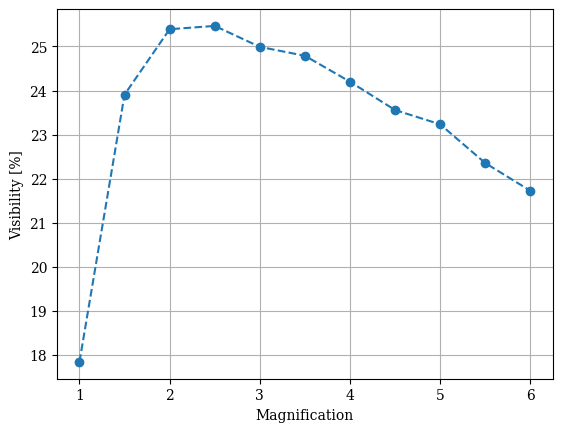

In [29]:
import matplotlib.pyplot as plt

plt.plot(magnifications, V*100, 'o--')
plt.xlabel("Magnification")
plt.ylabel("Visibility [%]")
plt.grid()
plt.show()

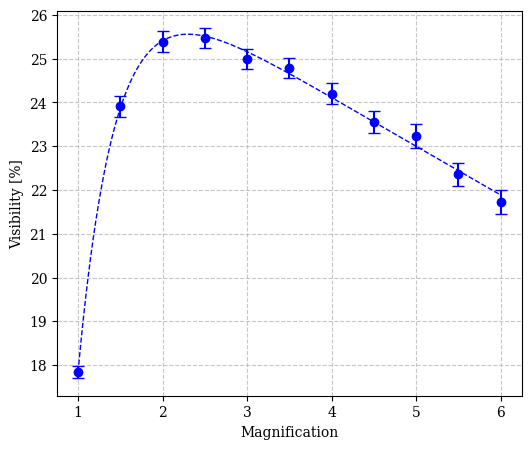

In [30]:
plt.figure(figsize=(6,5))
plt.errorbar(
    magnifications,
    V * 100,
    yerr=V_err * 100,
    fmt='o',
    capsize=4,
    color='blue',
)
plt.plot(x_fit, y_fit*100, '--', lw=1, color='blue')

# Línea punteada conectando
#plt.plot(magnifications, V * 100, '--',color='blue')

plt.xlabel("Magnification")
plt.ylabel("Visibility [%]")
plt.grid(linestyle='--', alpha=0.7)

os.makedirs("ARTICLE_RESULTS", exist_ok=True)
plt.savefig("ARTICLE_RESULTS/Visibility_vs_Magnification.png", dpi=300)
plt.savefig("ARTICLE_RESULTS/Visibility_vs_Magnification.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [11]:

def compute_visibility_x(img, block=50):

    mu_values = []
    gradx_values = []
    grady_values = []

    height, width = img.shape

    # gradiente en x
    grad_x = np.gradient(img, axis=1)
    grad_y = np.gradient(img, axis=0)

    for x in range(0, height - block + 1, block):
        for y in range(0, width - block + 1, block):

            region_I = img[x:x+block, y:y+block]
            region_gradx = grad_x[x:x+block, y:y+block]
            region_grady = grad_y[x:x+block, y:y+block]

            mu = np.mean(region_I)
            sigma_gradx = np.std(region_gradx)
            sigma_grady = np.std(region_grady)

            if mu > 0:
                mu_values.append(mu)
                gradx_values.append(sigma_gradx)
                grady_values.append(sigma_grady)

    mu_values = np.array(mu_values)
    gradx_values = np.array(gradx_values)
    grady_values = np.array(grady_values)

    mean_mu = np.mean(mu_values)
    mean_gradx = np.mean(gradx_values)
    mean_grady = np.mean(grady_values)

    visibility_x = mean_gradx / mean_mu
    visibility_y = mean_grady / mean_mu

    return visibility_x, visibility_y

In [12]:
vis_results_x = []
vis_results_y = []
magnifications = []

for file in files:

    # Leer RAW
    data_array = np.fromfile(file, dtype='float32', count=256*256)
    img = data_array.reshape(256, 256)

    # Calcular VIS
    vis_x, vis_y = compute_visibility_x(img)


    vis_results_x.append(vis_x)
    vis_results_y.append(vis_y)

    # Extraer el número de magnificación del nombre
    mag = file.split("Vis_")[1].split("X")[0]
    magnifications.append(float(mag))

print(magnifications)
print(vis_results_x, vis_results_y)

[1.5, 1.0, 2.5, 2.0, 3.5, 3.0, 4.5, 4.0, 5.5, 5.0, 6.0]
[0.1492269, 0.119024724, 0.13863832, 0.1492045, 0.10994907, 0.12510361, 0.08671924, 0.09747166, 0.07138466, 0.07887436, 0.06439053] [0.14966781, 0.11961025, 0.13854168, 0.1494606, 0.10981154, 0.12481717, 0.08732628, 0.0986544, 0.06995176, 0.079484, 0.064108655]


# SNR vs NUmber_SANDPAPERS

In [13]:
SNR_x = np.array([10.6, 12.51,13.41,14.21,14.65,14.5,15.12])
SNR_y = np.array([10.46,11.9,12.83,13.22,15.2,14.28,15.2])
Number_sands = np.array([1, 2, 3, 4, 6, 8, 10])

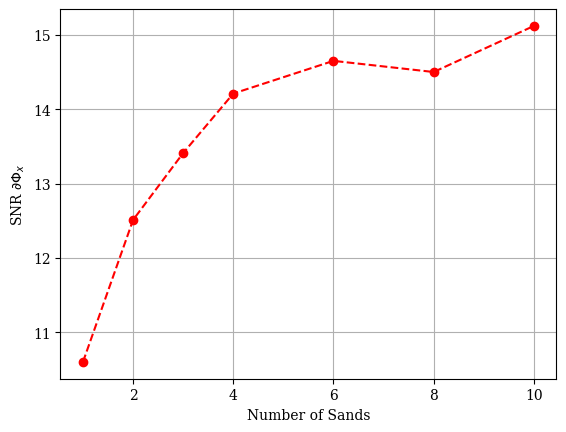

In [14]:
plt.plot(Number_sands, SNR_x, 'o--',color='red')
plt.xlabel("Number of Sands")
plt.ylabel("SNR $\partial \Phi_x$")
plt.grid()
plt.show()

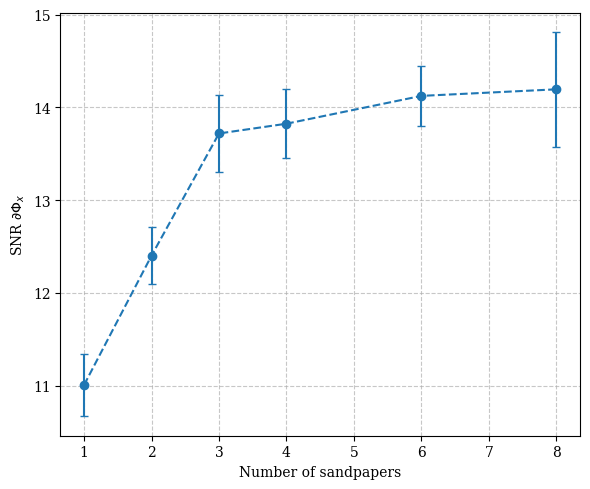

In [15]:

# Cargar archivo (separado por espacios)
data = np.loadtxt('ARTICLE_RESULTS/snrs_y_num_TiC.txt')

# Columnas
x = data[:, 0]
y = data[:, 1]
y_err = data[:, 2]

grado = 3
coef = np.polyfit(x, y, grado)
poly = np.poly1d(coef)

# Curva suave
x_fit = np.linspace(np.min(x),
                    np.max(x), 500)
y_fit = poly(x_fit)
# Plot con barras de error
plt.figure(figsize=(6,5))
plt.errorbar(x, y, yerr=y_err, fmt='o--', capsize=3)
#plt.plot(x_fit, y_fit, '--',color='red')

plt.xlabel('Number of sandpapers')
plt.ylabel('SNR $\partial \Phi_x$')
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("ARTICLE_RESULTS/SNR_Vs_NumberSANDS.png", dpi=300)
plt.savefig("ARTICLE_RESULTS/SNR_Vs_NumberSANDS.pdf", format="pdf", bbox_inches="tight")

plt.show()

Parámetros ajustados:
  C1 = 7.84089 ± 1.62361
  C2 = 6.44272 ± 1.44927
  C3 = 0.66160 ± 0.22825

Chi² reducido: 0.304


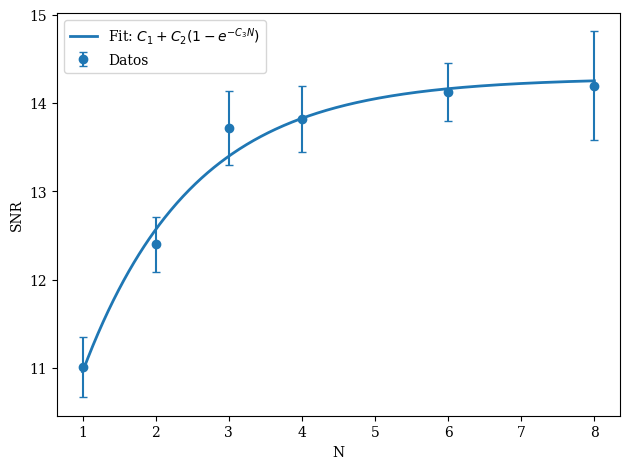

In [17]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# --- Tus datos ---
datos = np.array([
    [1.000000000000000000e+00, 1.100737580101133339e+01, 3.393361434809352151e-01],
    [2.000000000000000000e+00, 1.240212019096469831e+01, 3.103200767398990312e-01],
    [3.000000000000000000e+00, 1.371925217008283759e+01, 4.195087953926098234e-01],
    [4.000000000000000000e+00, 1.382451557168450229e+01, 3.734523890509508504e-01],
    [6.000000000000000000e+00, 1.412451557168450229e+01, 3.234523890509508504e-01],
    [8.000000000000000000e+00, 1.419515820654429916e+01, 6.180465004600316226e-01],
])

idx = np.argsort(datos[:, 0])
datos = datos[idx]

N = datos[:, 0]
SNR = datos[:, 1]
SNR_err = datos[:, 2]

# --- Modelo propuesto ---
def modelo(N, C1, C2, C3):
    return C1 + C2 * (1 - np.exp(-C3 * N))

# --- Estimaciones iniciales ---
p0 = [SNR.min(), SNR.max() - SNR.min(), 1.0]

# Bounds (C3 debe ser positivo)
bounds = ([-np.inf, -np.inf, 0], [np.inf, np.inf, np.inf])

popt, pcov = curve_fit(
    modelo, N, SNR,
    p0=p0,
    sigma=SNR_err,
    absolute_sigma=True,
    bounds=bounds,
    maxfev=10000
)

perr = np.sqrt(np.diag(pcov))

print("Parámetros ajustados:")
for nombre, val, err in zip(['C1', 'C2', 'C3'], popt, perr):
    print(f"  {nombre} = {val:.5f} ± {err:.5f}")

# --- Chi cuadrado reducido (bondad de ajuste) ---
residuos = SNR - modelo(N, *popt)
chi2 = np.sum((residuos / SNR_err)**2)
dof = len(N) - len(popt)  # grados de libertad
chi2_red = chi2 / dof
print(f"\nChi² reducido: {chi2_red:.3f}")

# --- Curva suave ---
x_fit = np.linspace(np.min(N), np.max(N), 500)
y_fit = modelo(x_fit, *popt)

# --- Gráfica ---
plt.errorbar(N, SNR, yerr=SNR_err, fmt='o', label='Datos', capsize=3)
plt.plot(x_fit, y_fit, '-', lw=2, color='C0',
         label='Fit: $C_1+C_2(1-e^{-C_3 N})$')
plt.xlabel("N")
plt.ylabel("SNR")
plt.legend()
plt.tight_layout()
plt.show()

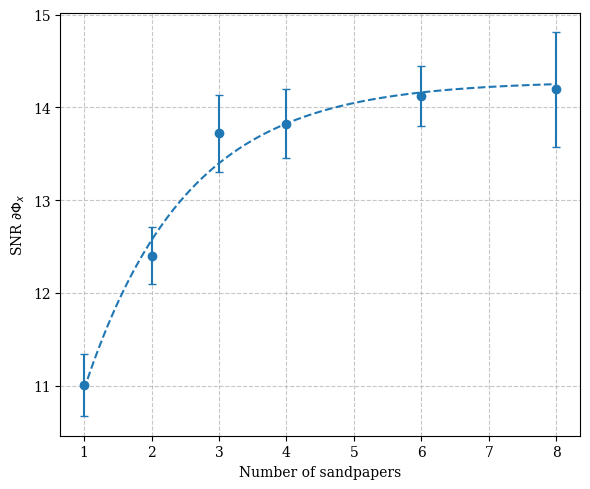

In [19]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Cargar archivo (separado por espacios)
data = np.loadtxt('ARTICLE_RESULTS/snrs_y_num_TiC.txt')

# Columnas
x = data[:, 0]
y = data[:, 1]
y_err = data[:, 2]

# --- Modelo propuesto ---
def modelo(x, C1, C2, C3):
    return C1 + C2 * (1 - np.exp(-C3 * x))

p0 = [y.min(), y.max() - y.min(), 1.0]
bounds = ([-np.inf, -np.inf, 0], [np.inf, np.inf, np.inf])

popt, pcov = curve_fit(
    modelo, x, y,
    p0=p0,
    sigma=y_err,
    absolute_sigma=True,
    bounds=bounds,
    maxfev=10000
)

# Curva suave
x_fit = np.linspace(np.min(x), np.max(x), 500)
y_fit = modelo(x_fit, *popt)

# Plot con barras de error
plt.figure(figsize=(6,5))
plt.errorbar(x, y, yerr=y_err, fmt='o', capsize=3, color='C0')
plt.plot(x_fit, y_fit, '--', color='C0')

plt.xlabel('Number of sandpapers')
plt.ylabel('SNR $\partial \Phi_x$')
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("ARTICLE_RESULTS/SNR_Vs_NumberSANDS.png", dpi=300)
plt.savefig("ARTICLE_RESULTS/SNR_Vs_NumberSANDS.pdf", format="pdf", bbox_inches="tight")

plt.show()

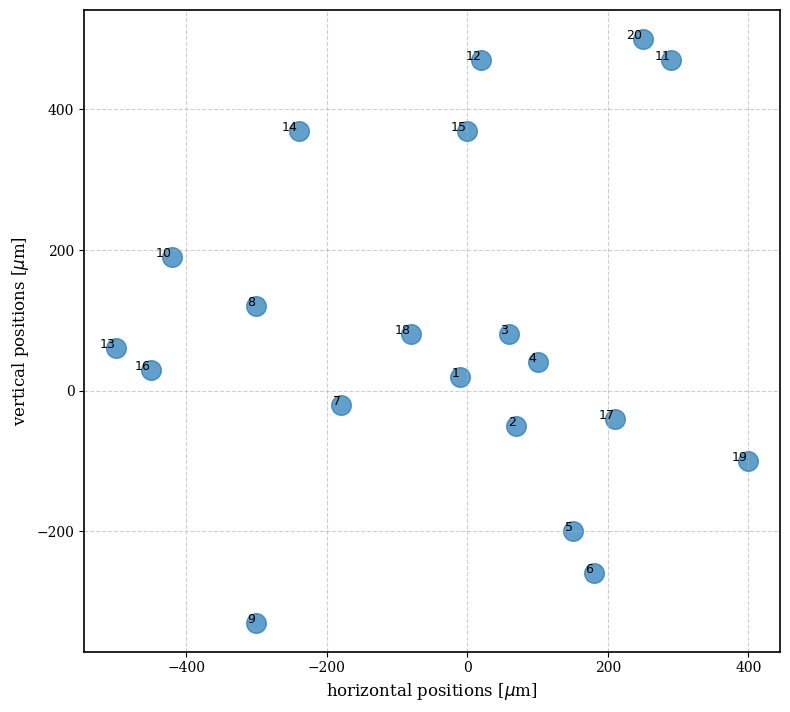

In [29]:
import matplotlib.pyplot as plt

a = [-10, 70, 60, 100, 150, 180, -180, -300, -300, -420,
     290, 20, -500, -240, 0, -450, 210, -80, 400, 250]

b = [20, -50, 80, 40, -200, -260, -20, 120, -330, 190,
     470, 470, 60, 370, 370, 30, -40, 80, -100, 500]

fig, ax = plt.subplots(figsize=(8, 8))

# Scatter
ax.scatter(a, b,s=200,alpha=0.7)

# Etiquetas p_i
for i, (x, y) in enumerate(zip(a, b), start=1):
    ax.text(x, y, f'${{{i}}}$', fontsize=9, ha='right')

# Recuadro completo (activar todos los bordes)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

# Labels de ejes
ax.set_xlabel('horizontal positions [$\mu$m]', fontsize=12)
ax.set_ylabel('vertical positions [$\mu$m]', fontsize=12)

# Grid
ax.grid(True, linestyle='--', alpha=0.6)

# Mantener proporciones tipo plano cartesiano real
ax.set_aspect('equal', 'box')

plt.tight_layout()
plt.savefig("ARTICLE_RESULTS/Positions.png", dpi=300)
plt.savefig("ARTICLE_RESULTS/Positions.pdf", format="pdf", bbox_inches="tight")
plt.show()

(-0.5, 1799.5, 1499.5, -0.5)

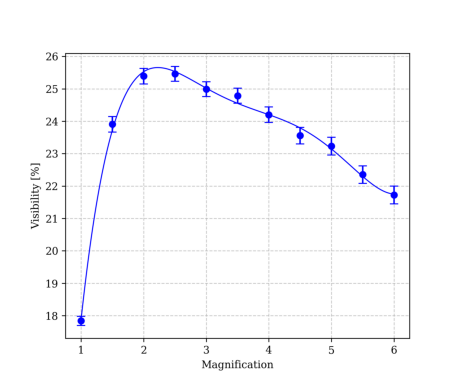

In [30]:
vis_vs_mag = plt.imread("ARTICLE_RESULTS/Visibility_vs_Magnification.png")
sand_vs_number = plt.imread("ARTICLE_RESULTS/SNR_Vs_NumberSANDS.png")
positions = plt.imread("ARTICLE_RESULTS/Positions.png")
plt.imshow(vis_vs_mag)
plt.axis('off')


In [31]:
import cv2
target_size = (1200, 1200)

vis_vs_mag = cv2.resize(vis_vs_mag, target_size)
sand_vs_number = cv2.resize(sand_vs_number, target_size)
positions = cv2.resize(positions, target_size)

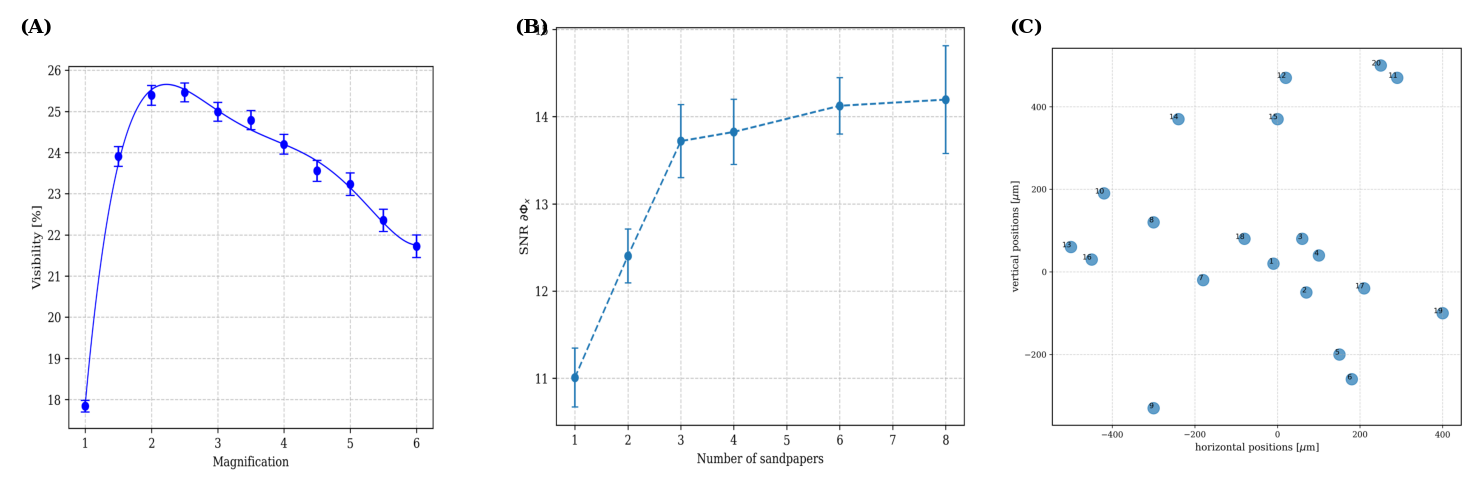

In [32]:


# Crear figura con 3 paneles
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Mostrar imágenes
axes[0].imshow(vis_vs_mag)
axes[1].imshow(sand_vs_number)
axes[2].imshow(positions)

# Quitar ejes
for ax in axes:
    ax.axis('off')

# Añadir etiquetas tipo paper
axes[0].annotate("(A)", xy=(0.02, 0.95), xycoords='axes fraction',
                 fontsize=14, fontweight='bold')
axes[1].annotate("(B)", xy=(0.02, 0.95), xycoords='axes fraction',
                 fontsize=14, fontweight='bold')
axes[2].annotate("(C)", xy=(0.02, 0.95), xycoords='axes fraction',
                 fontsize=14, fontweight='bold')

plt.tight_layout()

# Guardar figura compuesta
plt.savefig("ARTICLE_RESULTS/Figure_Combined.png",
            dpi=300, bbox_inches='tight')

plt.savefig("ARTICLE_RESULTS/Figure_Combined.pdf",
            bbox_inches='tight')

plt.show()

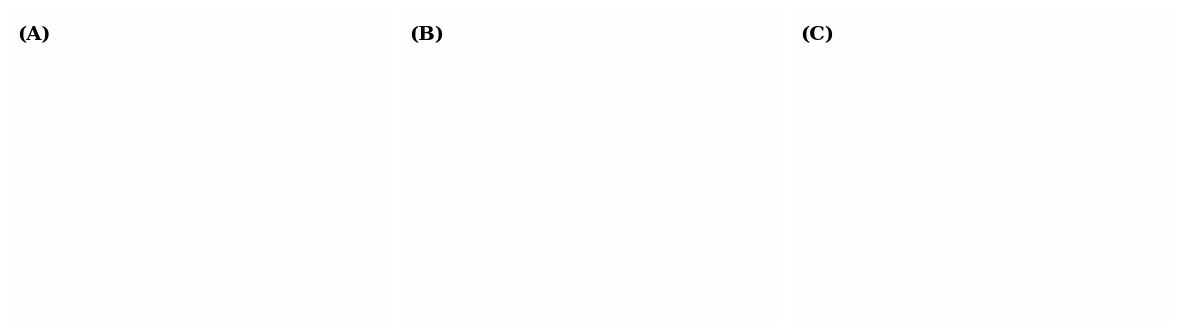

In [33]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# --- Cargar imágenes ---
imgs = [Image.fromarray(p.astype('uint8')) for p in [vis_vs_mag, sand_vs_number, positions]]

# --- Forzar mismo tamaño en píxeles ---
target_size = (600, 500)  # ancho x alto, ajusta a tu gusto
imgs_resized = [np.array(img.resize(target_size, Image.LANCZOS)) for img in imgs]

# --- Figura ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                         gridspec_kw={'wspace': 0.03})

labels = ["(A)", "(B)", "(C)"]
for ax, img, label in zip(axes, imgs_resized, labels):
    ax.imshow(img, aspect='equal')
    ax.axis('off')
    ax.annotate(label, xy=(0.02, 0.95), xycoords='axes fraction',
                fontsize=14, fontweight='bold', color='black',
                va='top')

plt.savefig("ARTICLE_RESULTS/Figure_Combined.png", dpi=300, bbox_inches='tight')
plt.savefig("ARTICLE_RESULTS/Figure_Combined.pdf", bbox_inches='tight')
plt.show()

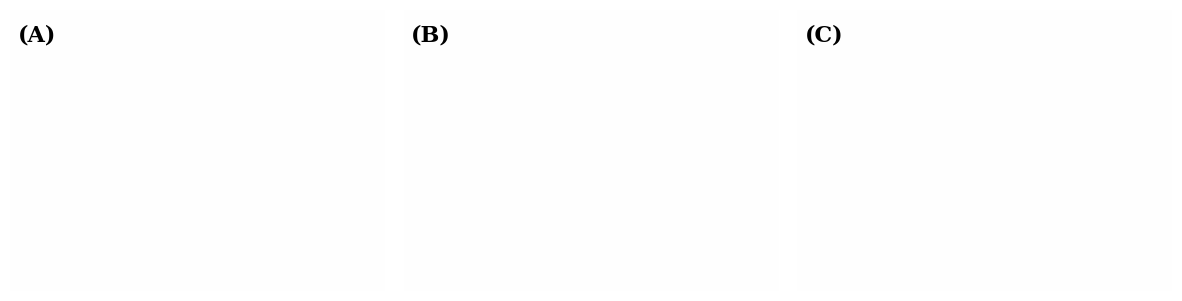

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Convertir tus arrays actuales a objetos de imagen de PIL para redimensionar
# Usamos .astype('uint8') para asegurar que el formato sea compatible
raw_data = [vis_vs_mag, sand_vs_number, positions]
imgs_pil = [Image.fromarray(img.astype('uint8')) for img in raw_data]

# 2. Forzar el mismo tamaño para que los paneles se vean simétricos
target_size = (800, 600)  # (ancho, alto)
imgs_resized = [np.array(img.resize(target_size, Image.LANCZOS)) for img in imgs_pil]

# 3. Crear la figura de Matplotlib
fig, axes = plt.subplots(1, 3, figsize=(15, 5), gridspec_kw={'wspace': 0.05})

labels = ["(A)", "(B)", "(C)"]

for i, ax in enumerate(axes):
    # Mostramos la imagen ya redimensionada
    ax.imshow(imgs_resized[i])
    ax.axis('off')
    
    # Añadir etiqueta (A), (B), (C)
    ax.annotate(labels[i], xy=(0.02, 0.95), xycoords='axes fraction',
                fontsize=16, fontweight='bold', color='black',
                va='top', ha='left')

# 4. Guardar ANTES de plt.show()
# Nota: plt.show() limpia la memoria de la figura en algunos entornos, 
# por eso siempre se guarda primero.
plt.savefig("ARTICLE_RESULTS/Figure_Combined.png", dpi=300, bbox_inches='tight')
plt.savefig("ARTICLE_RESULTS/Figure_Combined.pdf", bbox_inches='tight')

plt.show()